# Fishing for PACE Data in Polygons

## Wrangling shape files

In the fisheries world, we don't always care about **every pixel in the ocean.** Often, we’re interested in environmental conditions across a particular area of interest, e.g., a fishing ground, habitat type, management boundary, aquaculture site, etc. These spatial extents are frequently defined using shapefiles, and if you work with fisheries scientists or managers, chances are you’ll encounter data prepared in ArcGIS. Python (and geopandas, in particular) handles these files well, but there are a few nuances when shapefiles need to “talk” to satellite data. We're going to explore the process of importing polygons and "clipping" our data to the same boundaries. 

> Learning Objectives:  

> 1. Import, explore, and display a shape file for Large Marine Ecosystems
> 2. Clip PACE data to the shape of a polygon and quantify the biomass within

## *Are you ready?*

## Let’s dive in! 🐠


## The shape of my heart... and LMEs

I grabbed the following shape file from https://github.com/datasets/lme-large-marine-ecosystems. An LME, or Large Marine Ecosystem, is a large ocean region defined by ecological criteria like bathymetry, hydrography, and productivity, with boundaries extending from river basins to the continental shelf. There are 66 defined LMEs globally, and the concept is used for ecosystem-based management to promote international cooperation on issues like sustainable fishing, pollution reduction, and climate change adaptation across these shared marine areas. First, let's open it and see what [Coordinate Reference System (CRS)](https://en.wikipedia.org/wiki/Spatial_reference_system) it is using. 

In [1]:
import geopandas as gpd

gdf = gpd.read_file('/home/jovyan/2025-tutorials/Supporting_files/lme66.shp')

# The Coordinate Reference System (CRS) is stored in the .crs attribute
current_crs = gdf.crs
print(f"\n🗺️ The shapefile's Coordinate Reference System (CRS) is:")
print(current_crs)


🗺️ The shapefile's Coordinate Reference System (CRS) is:
EPSG:4326


Whew. Good thing. This is the same reference system used for most satellite files (WGS84), so they should play nicely. But, if you run into a file that has another projection, the code below will get you aligned. 

In [2]:
# In this case the CRS is EPSG:4326, which is a common standard for satellite data. 
# If this is NOT the case, you can convert the coordinate system:

gdf_wgs84 = gdf.to_crs("EPSG:4326")
gdf_wgs84

,OBJECTID,LME_NUMBER,LME_NAME,Shape_Leng,Shape_Area,geometry
0,1,23.0,Baltic Sea,219.326402,61.950021,"POLYGON ((10.97944 54.38055, 10.98611 54.37805..."
1,2,52.0,Sea of Okhotsk,145.932989,213.796584,"POLYGON ((156.70705 51.18858, 156.62592 51.160..."
2,3,22.0,North Sea,209.486403,103.965247,"POLYGON ((5.27889 61.98027, 5.24917 61.97388, ..."
3,4,2.0,Gulf of Alaska,468.695688,203.793868,"POLYGON ((-124.59823 47.90313, -125.85582 47.0..."
4,5,9.0,Labrador - Newfoundland,270.847479,114.597691,"MULTIPOLYGON (((-64.56793 60.45509, -60.09442 ..."
...,...,...,...,...,...,...
61,62,63.0,Hudson Bay Complex,391.717406,209.464313,"MULTIPOLYGON (((-64.79667 59.98027, -64.81194 ..."
62,63,55.0,Beaufort Sea,478.747080,292.450949,"POLYGON ((-122.68333 76.0198, -122.6989 76.018..."
63,64,66.0,Canadian High Arctic - North Greenland,1059.501342,297.732265,"MULTIPOLYGON (((-122.5625 76.01443, -122.56585..."
64,65,64.0,Central Arctic,760.568294,3181.188855,"POLYGON ((180 75.98248, 179.29807 75.97633, 17..."


## Examining the polygons 

Let's see where all these polygons are!

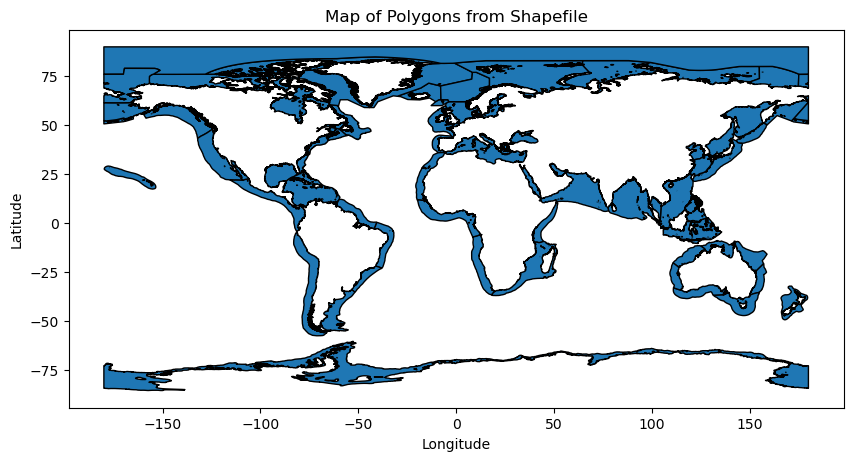

In [3]:
import matplotlib.pyplot as plt

# Plot the GeoDataFrame
gdf.plot(edgecolor='black', figsize=(10, 10))
plt.title("Map of Polygons from Shapefile")
plt.xlabel("Longitude") 
plt.ylabel("Latitude") 
plt.show()

## Getiing more specific

We can see the names of the column headers when we initially examined the contents of the file. However, it was truncated. Let's print out the entire list so we can see what LMEs are all contained within

In [4]:
import pandas as pd

# Select relevant columns
lme_reference_df = gdf[['LME_NUMBER', 'LME_NAME']]

# Sort the table by the LME_NUMBER (from 1.0 to 66.0)
lme_reference_df = lme_reference_df.sort_values(by='LME_NUMBER').reset_index(drop=True)

# Use pd.option_context to temporarily ensure all 66 rows are displayed
with pd.option_context('display.max_rows', 70):
    print("Full List of LMEs (Sorted by LME_NUMBER):")
    print(lme_reference_df)

Full List of LMEs (Sorted by LME_NUMBER):
    LME_NUMBER                                  LME_NAME
0          1.0                           East Bering Sea
1          2.0                            Gulf of Alaska
2          3.0                        California Current
3          4.0                        Gulf of California
4          5.0                            Gulf of Mexico
5          6.0          Southeast U.S. Continental Shelf
6          7.0          Northeast U.S. Continental Shelf
7          8.0                             Scotian Shelf
8          9.0                   Labrador - Newfoundland
9         10.0                  Insular Pacific-Hawaiian
10        11.0          Pacific Central-American Coastal
11        12.0                             Caribbean Sea
12        13.0                          Humboldt Current
13        14.0                          Patagonian Shelf
14        15.0                        South Brazil Shelf
15        16.0                         East Br

# Let's just grab a few

You can arrange the code to ingest the LME_NUMBER, if you like, but here we opted to use the full LME_NAME.

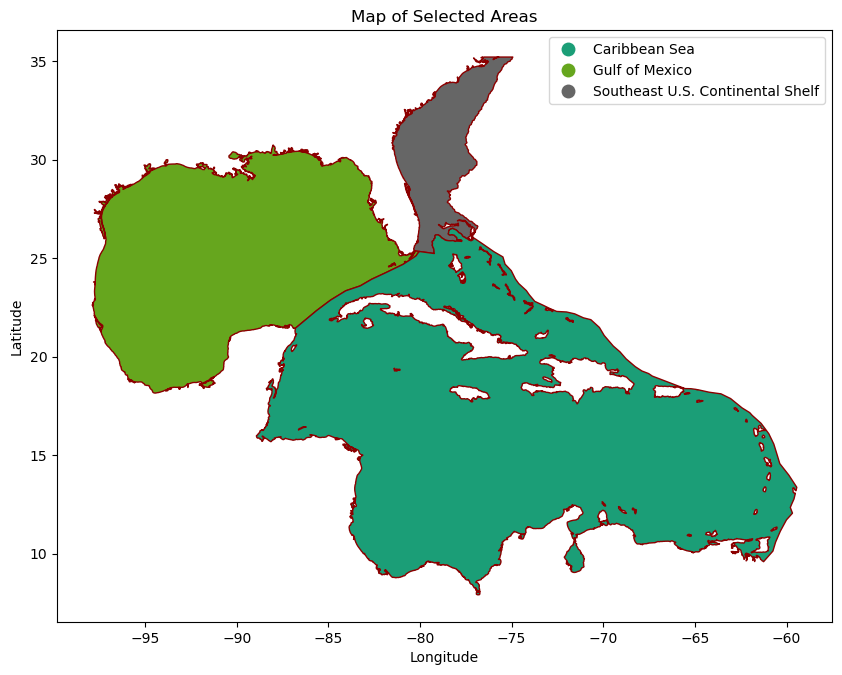

In [5]:
import matplotlib.pyplot as plt

# Define the specific LME names you want to plot
selected_names = ['Southeast U.S. Continental Shelf', 'Gulf of Mexico', 'Caribbean Sea']

# Filter the GeoDataFrame using .isin()
selection_gdf_names = gdf[gdf['LME_NAME'].isin(selected_names)]

# Plot the filtered GeoDataFrame
selection_gdf_names.plot(
    column='LME_NAME', # Use the name column for distinct coloring
    legend=True,
    cmap='Dark2',
    edgecolor='darkred',
    linewidth=1.0,
    figsize=(10, 10)
)

plt.title("Map of Selected Areas")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Enough shaping around! Let's get some PACE data!

In some cases, it might be usedful to extract satellite data only from within a certain boundary (e.g., a Marine Protected Area). In this case, it may be useful to clip your satellite data down to the size of your shapefile so you're not lugging around a global Level-3 file for your analyses. First, let's grab our data - old reliable chlorophyll-a.

In [6]:
import earthaccess
import xarray as xr
auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_CHL",
    temporal = ("2024-01-01", "2024-12-31"),
    granule_name="*.SNSU.*.4km.*"
)
fileset = earthaccess.open(results);

# Load relevant datasets
dataset = xr.open_dataset(fileset[0])
latitude = dataset["lat"]
longitude = dataset["lon"]
CHL = dataset["chlor_a"]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

## Rio!!

Over the course of these tutorials, we've been largely dealing with xarray when dealing with satellite data. However, xarray alone does not understand geospatial boundaries. xarray is great for labeled N-dimensional arrays, but it has no built-in understanding of coordinate reference systems (CRS), spatial dimensions (lat/lon), geospatial polygon clipping, or reprojection. In other words, you are going to struggle to get your shapefile to cooperate with you because they are generally made with GIS applications in mind. If you try to clip or mask using only xarray, you have to manually build a mask array at the grid resolution, which is slow, verbose, and error-prone. 

Below, rio.clip() performs polygon masking correctly and efficiently. Funny little nuance though, since rioxarray is built on top of rasterio (a GIS-friendly python library), it follows classic GIS conventions where x = horizontal coordinates (i.e., longitude), and y = vertical coordiantes (i.e., latitude). Yeah, we have to tell it that explicitly, and then go back and re-define the coordinate reference system for your satellite image, but this is the way (*this is the way*).

Alright, pick an LME of your preference and specify below:

In [7]:
import rioxarray # For clipping satellite data

# Select your LME of choice from the list we generated earlier
lme_name = 'Gulf of Mexico'
LME = gdf[gdf['LME_NAME'] == lme_name]

# rioxarray requires coordinates to be set as dimensions
CHL_xy = CHL.rename({"lon": "x", "lat": "y"})
CHL_xy = CHL_xy.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)

# Assign the CRS (PACE L3 data is WGS 84, which is EPSG:4326)
CHL_xy = CHL_xy.rio.write_crs("EPSG:4326")

# Reprojected LME polygon to match AVW data CRS
# We already know that the CRS matches, but this is useful tidbit if it doesn't
LME_4326 = LME.to_crs(CHL_xy.rio.crs)

# Clip the AVW data to the LME boundary
CHL_clipped = CHL_xy.rio.clip(
    LME_4326.geometry.values,
    LME_4326.crs
)

## Let's check it out!

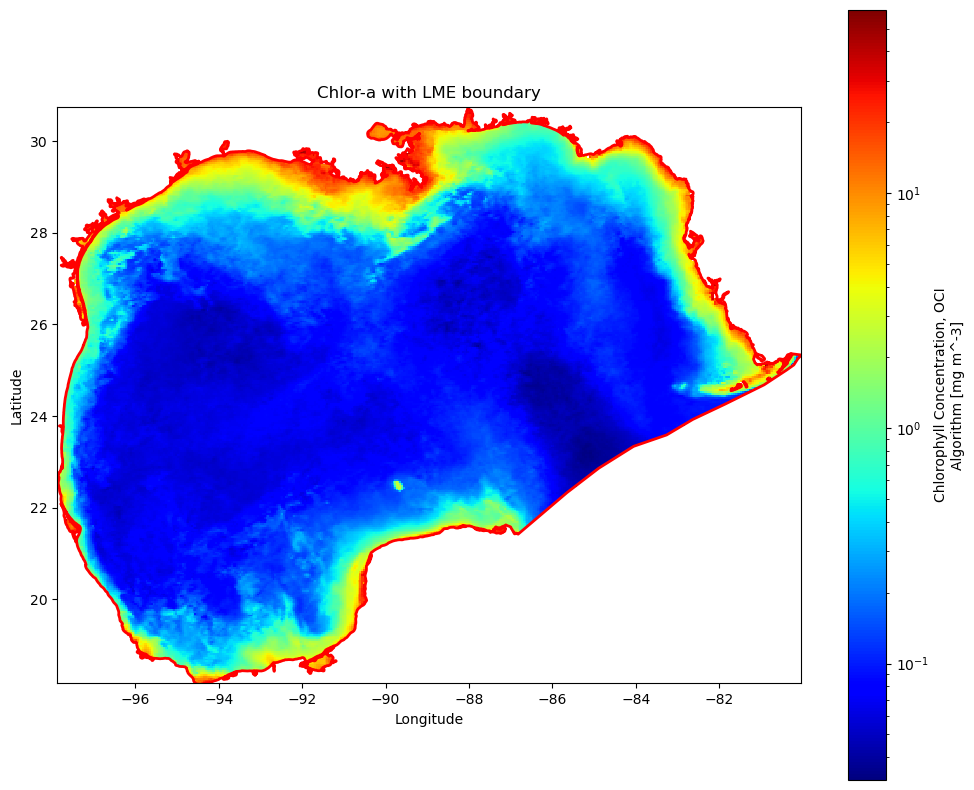

In [9]:
import matplotlib.colors as colors

fig, ax = plt.subplots(figsize=(12,10))
CHL_clipped.plot(ax=ax, cmap='jet', add_colorbar=True, norm=colors.LogNorm())
LME_4326.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)

plt.title("Chlor-a with LME boundary")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## How much chlorophyll biomass is in the Gulf? 

Now that we’ve isolated this area, are you curious how much chlorophyll biomass is actually represented in this image? We can estimate that! Here's ho wwe go about it: 

> 1. Integrate the surface signal down through the euphotic layer using the empirical relationships from [Morel and Berthon (1989)](https://doi.org/10.4319/lo.1989.34.8.1545)*. They analyzed thousands of vertical pigment profiles in open-ocean waters and found that the total chlorophyll in the water column can be inferred from surface concentrations. Think of it as a shortcut: we don’t have to measure every meter of depth, we just use the surface as a clue. 

> 2. Account for pixel size. Each satellite pixel covers 4 × 4 km of ocean, so we multiply the depth-integrated chlorophyll by the area represented by each pixel.

> 3. Sum over all pixels in the Gulf. Now we have an estimate of the total chlorophyll biomass for the whole region.

> 4. Convert units from milligrams to kilograms, because reporting millions of milligrams is unwieldy.

>**Heads-up: Morel and Berthon’s relationships are optimized for Case-1, open-ocean waters. In coastal regions, where sediments or colored dissolved organic matter interfere with the signal, these estimates become less reliable. In other words, we're in "back of the envelope" territory here. But this gives us a first-pass, region-scale look at phytoplankton biomass / trophic energy potential, and it's perfect for exploring spatial patterns and seasonal variability, even if the exact numbers are a bit fuzzy.*

Executed, it looks something like this:

In [48]:
CHL_valid = CHL_clipped.where(CHL_clipped > 0)
# Here are the old school Case-1 (i.e. open ocean) assumptions to integrate chlorophyll-a with depth
chl_int = xr.where(CHL_valid < 1.0,
    38.0 * CHL_valid**0.425,
    40.2 * CHL_valid**0.507
)

# chl_int is units of mg Chl m⁻² per pixel
pixel_area = 4_000 * 4_000 
chl_biomass = ((chl_int * pixel_area).sum(dim=("x", "y"), skipna=True)) / 1000000 # converts to kg
print(f"Area + Depth-integrated chlorophyll-a following Morel and Berthon 1989: {chl_biomass.values:.2e} kg Chl-a")


Area + Depth-integrated chlorophyll-a following Morel and Berthon 1989: 3.34e+07 kg Chl-a


## There you have it!

Polygons and PACE! Hopefully you now find it easier to talk across disciplines and folks with a more GIS-oriented background. 